## Analysing the density of performances based on the IAAF Score over the years

Hypothesis: Performance density is decreasing over the years

In [65]:
# Load data

import sys
from pathlib import Path

# Path to the parent folder (where util.py is)
parent_path = Path().resolve().parent.parent  # notebook's parent directory
sys.path.append(str(parent_path))
import util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import help_functions as hp

data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\Data.csv') 

data.head()

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146


Data clearing of outliers and defining discipline groups for further investigation

In [66]:
# Exclude outliers that are not explainable

data = data[(data["iaaf_score"] < 1380) & (data["iaaf_score"] > 20)]

# Define Discipline groups NOTE: Only the ones with clear data

run_disciplines = ['800 m', '1500 m', '3000 m', '5000 m', '10 km']
sprint_disciplines = ['100 m', '200 m', '400 m']
throw_disciplines = ['Kugelstoss', 'Diskuswurf', 'Hammerwurf', 'Speerwurf']
jump_disciplines = ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']

# Combine all into a single list
all_disciplines = run_disciplines + sprint_disciplines + throw_disciplines + jump_disciplines

data = data[data["disziplin"].isin(all_disciplines)]

### How is the performance evolving for the elite (e.g. Top 3) in comarison to the second/third row (e.g. Top 10/20/30) over the years

**NOTE**: Not more than top 30 to have always the same amount of data for comparability

1. The top-X performances are taken for every discipline x gender x age group seperatly -> calculation of mean and standard deviation for every group

2. We first look at all disciplines/Gender/Age Group together -> mean aggregated over all groups per year

3. Plotting the difference of mean performance to the first recorded year, e.g. 2001 -> over 1.0 -> increase in peformance, under 1.0 -> decrease in performance 

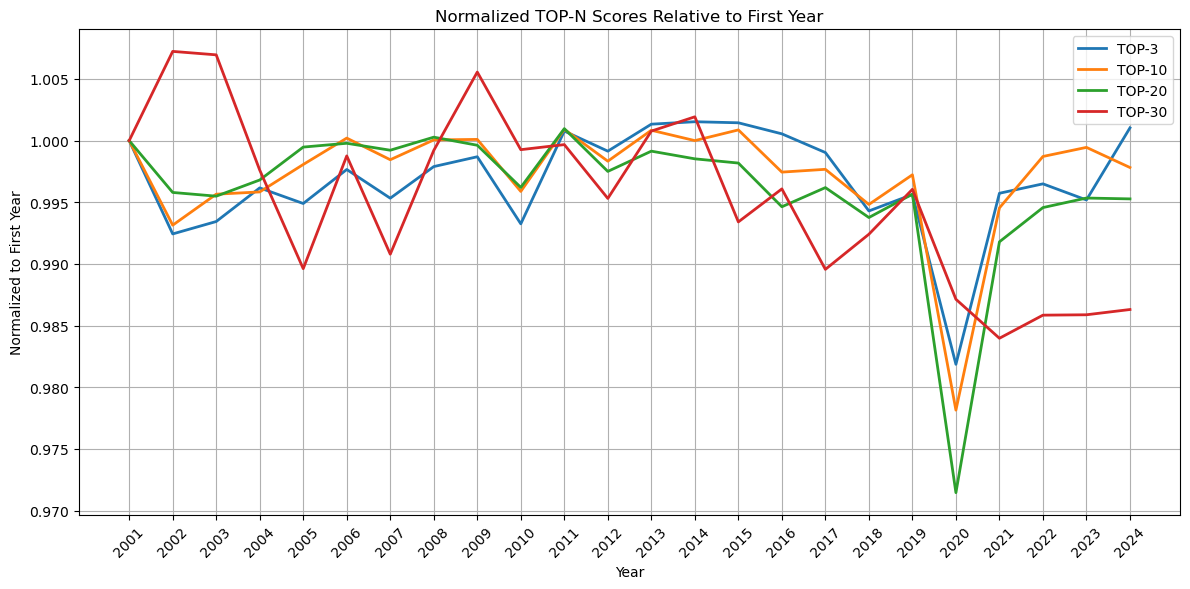

In [67]:
import matplotlib.pyplot as plt 
import pandas as pd 

top_entries_list = [3, 10, 20, 30] 
normalized_stats_list = [] 

for n in top_entries_list: 
    # Collect top-N entries
    top_raw = hp.collect_top_entries(data, num_entries=n) 
    if top_raw.empty: 
        continue 
    
    # Compute mean TOP-N per year
    top_n_mean = top_raw.groupby("jahr")["iaaf_score"].mean().reset_index(name="top_mean") 
    
    # Normalize to first year
    first_year_value = top_n_mean["top_mean"].iloc[0] 
    top_n_mean["normalized"] = top_n_mean["top_mean"] / first_year_value 
    
    # Add a column with number of entries for legend
    top_n_mean["num_entries"] = n
    
    # Append to list
    normalized_stats_list.append(top_n_mean) 
    
# Plot normalized TOP-N scores
plt.figure(figsize=(12, 6)) 

for stats in normalized_stats_list: 
    plt.plot(stats["jahr"], stats["normalized"], label=f"TOP-{stats['num_entries'].iloc[0]}", linewidth=2) 

plt.xlabel("Year") 
plt.ylabel("Normalized to First Year") 
plt.title("Normalized TOP-N Scores Relative to First Year") 
plt.legend() 
plt.grid(True) 
plt.xticks(sorted(data["jahr"].unique()), rotation=45) 
plt.tight_layout() 
plt.show()


#### Interpretation

- We can see a clear drop in 2020 (Corona performances)
- Top 30 is decreasing more or less since 2014 (no Corona effect; Top Performances more affected?!)



### Looking at the overall density of performances e.g. the Standard deviation

Standard deviation is a good indicator of how dense a distribution is

- p-value -> tests the null hypothesis that the slope of the regression line is zero (e.g. no relationship)
- R^2 -> Explains how much of variation in dependent variable (e.g. std dev) is explained by independent variable (e.g. years) (Range 0: Dependent explains no variation; 1: Dependent explains all variation)

In the following, one can see the difference if normalization to the first year is done "within group" (mean in a discipline) and "in between group" (mean per year in relation to first year)

c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x000001C7D09A8F40> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)


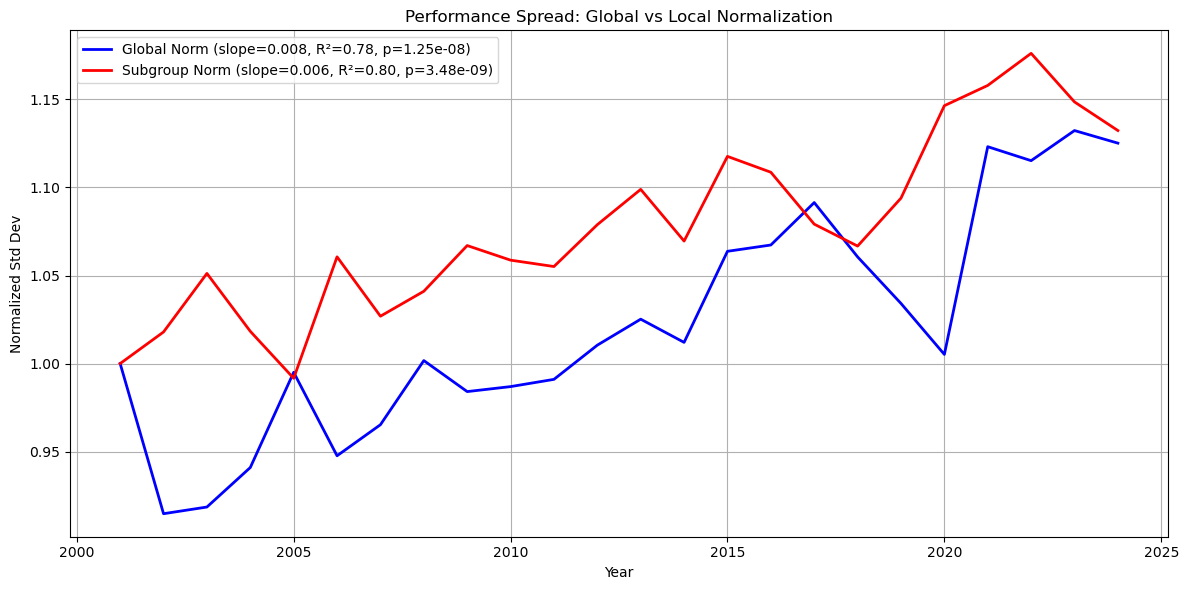

In [68]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import statsmodels.api as sm

# --- Global normalization ---
top_raw = hp.collect_top_entries(data, num_entries=30)

global_std = top_raw.groupby('jahr')['iaaf_score'].std()
global_std_norm = global_std / global_std.iloc[0]  # normalize to 2001

# Linear regression
X, model_global, slope_global, r2_global, p_global = hp.linear_regression(global_std_norm)

# --- local normalization
norm_data = hp.func_norm_per_group(top_raw, np.std)

X, model_local, slope_local, r2_local, p_local = hp.linear_regression(norm_data)

# --- 3. Plot ---
plt.figure(figsize=(12,6))
plt.plot(global_std_norm.index, global_std_norm.values, color='blue', linewidth=2,
         label=f'Global Norm (slope={slope_global:.3f}, R²={r2_global:.2f}, p={p_global:.2e})')
plt.plot(norm_data.index, norm_data.values, color='red', linewidth=2,
         label=f'Subgroup Norm (slope={slope_local:.3f}, R²={r2_local:.2f}, p={p_local:.2e})')
plt.xlabel("Year")
plt.ylabel("Normalized Std Dev")
plt.title("Performance Spread: Global vs Local Normalization")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


#### Interpretation

Standard deviation is clearly increasing -> drop in performance density

There clearly is an significant effect nevertheless if subgroup or global normalization. 

### Looking at age group, gender, discipline to find the disciplines that are struggling

1. Idea: Looking at the discipline groups; That is a division the DLV is doing (and makes sense to me)

2. Looking at gender

3. Looking at age groups x gender

To further exclude absolute performance differences all calculations are done with normalization in the subgroups (Especially in running e.g. longer distances the differences are naturally higher)


c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x000001C7D09A8F40> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x000001C7D09A8F40> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x000001C7D09A8F40

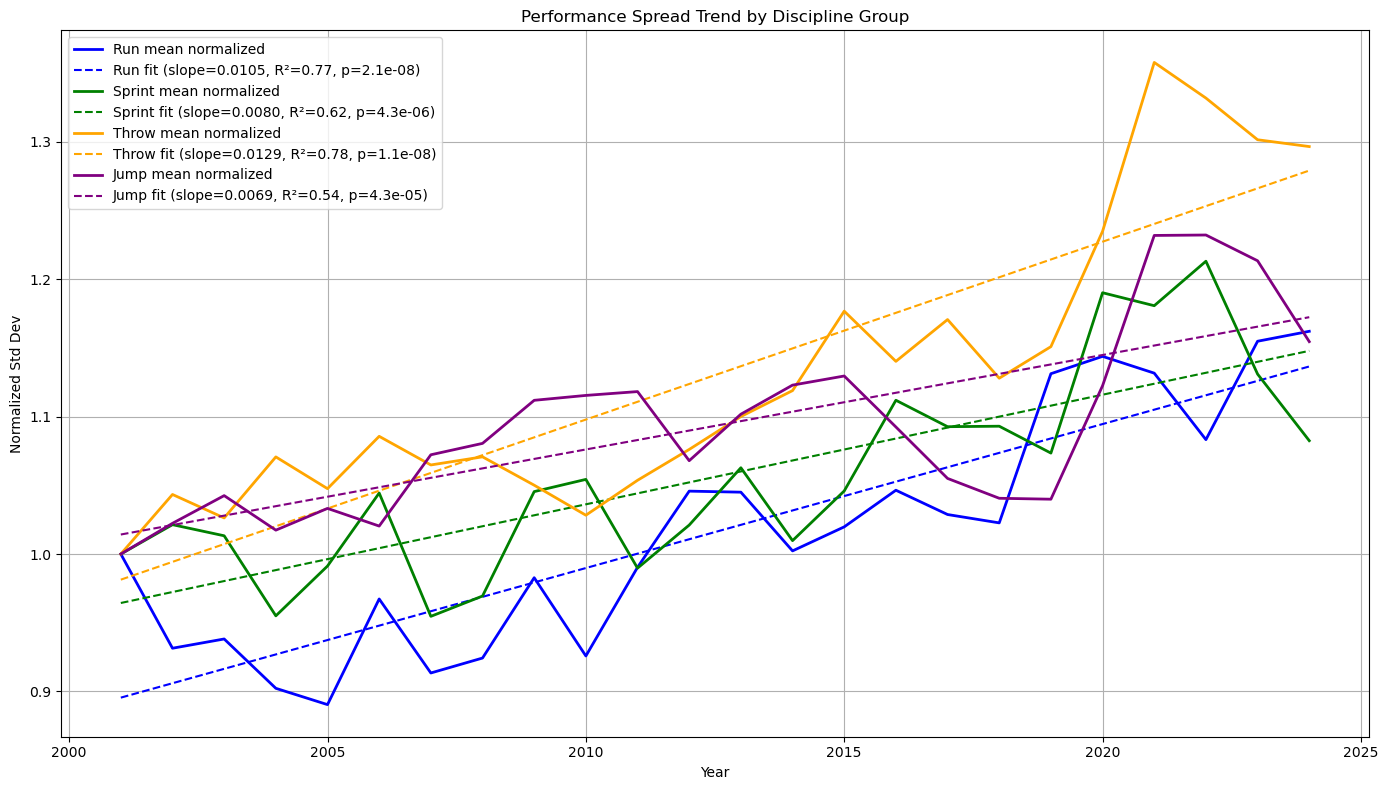

In [69]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd

groups = {
    'Run': run_disciplines,
    'Sprint': sprint_disciplines,
    'Throw': throw_disciplines,
    'Jump': jump_disciplines
}

plt.figure(figsize=(14,8))

colors = {
    'Run': 'blue',
    'Sprint': 'green',
    'Throw': 'orange',
    'Jump': 'purple'
}

# Loop over discipline groups
for group_name, disciplines in groups.items():

    group_data = data[data['disziplin'].isin(disciplines)]

    mean_norm = hp.func_norm_per_group(group_data, np.std)
    
    X, model, slope, r2, p_value = hp.linear_regression(mean_norm)

    regression_line = model.predict(X)

    years = mean_norm.index.values.astype(float)

    # Plot mean normalized values
    plt.plot(years, mean_norm.values, color=colors[group_name], linewidth=2, label=f"{group_name} mean normalized")

    # Plot regression line
    plt.plot(years, regression_line, linestyle="--", color=colors[group_name], label=f"{group_name} fit (slope={slope:.4f}, R²={r2:.2f}, p={p_value:.1e})")


plt.xlabel("Year")
plt.ylabel("Normalized Std Dev")
plt.title("Performance Spread Trend by Discipline Group")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x000001C7D09A8F40> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithC

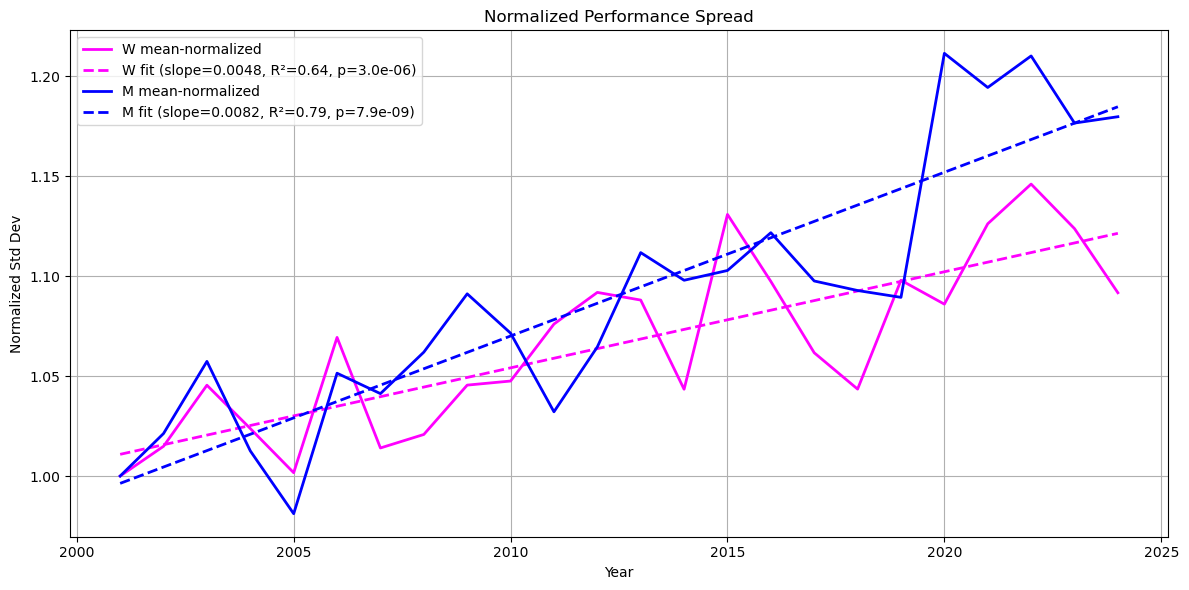

In [70]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import pandas as pd
import numpy as np

genders = ["W", "M"]
colors = {"W": "magenta", "M": "blue"}

plt.figure(figsize=(12, 6))

for gender in genders:
    
    gender_data = data[data["geschlecht"] == gender]

    #Get top 30 data
    gender_data = hp.collect_top_entries(gender_data, 30)

    norm_data_per_gender = hp.func_norm_per_group(gender_data, np.std)

    X, model, slope, r2, p_value = hp.linear_regression(norm_data_per_gender)

    regression_line = model.predict(X)

    years = mean_norm.index.values.astype(float)

    # normalized curve
    plt.plot(years, norm_data_per_gender.values, color=colors[gender], linewidth=2, label=f"{gender} mean-normalized")

    # Regression line
    plt.plot(years, regression_line, "--",color=colors[gender], linewidth=2, label=f"{gender} fit (slope={slope:.4f}, R²={r2:.2f}, p={p_value:.1e})")


plt.xlabel("Year")
plt.ylabel("Normalized Std Dev")
plt.title("Normalized Performance Spread")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x000001C7D09A8F40> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithC

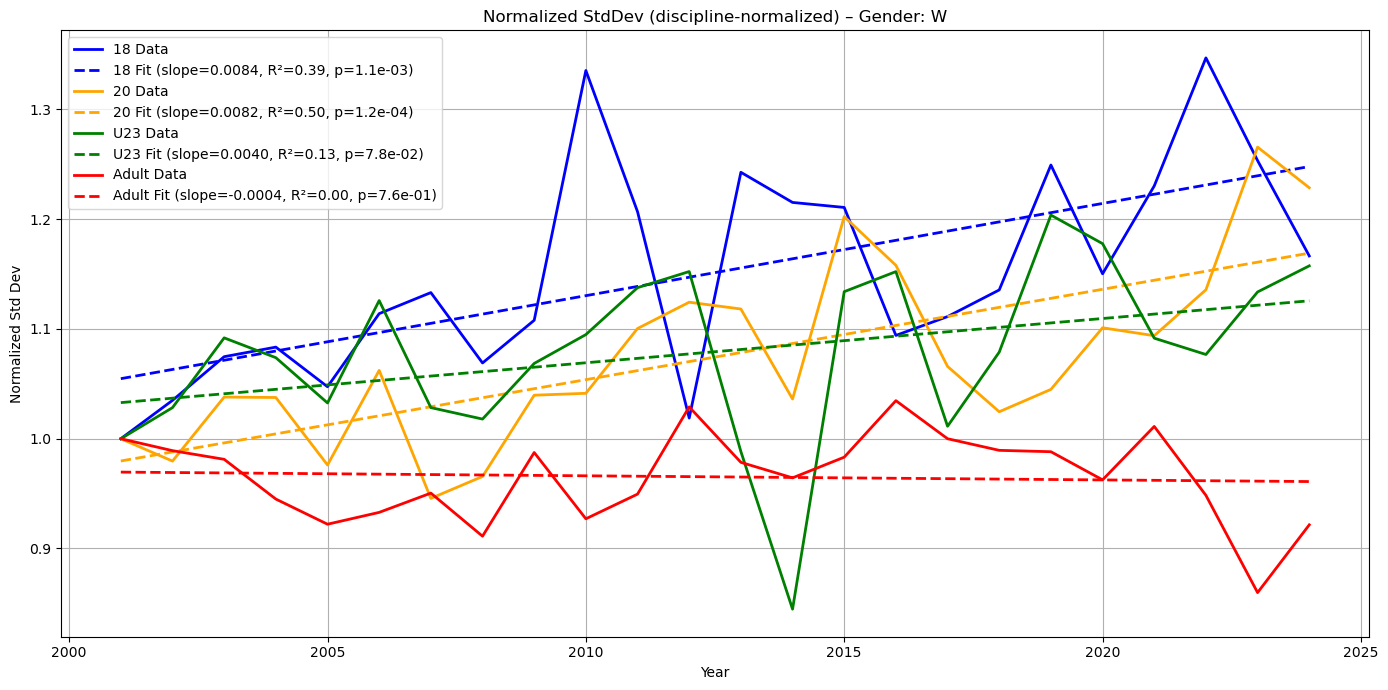

c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["iaaf_score"] = pd.to_numeric(data["iaaf_score"], errors="coerce")
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:47: FutureWarning: The provided callable <function std at 0x000001C7D09A8F40> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  group = subdata.groupby("jahr")["iaaf_score"].agg(func)
c:\Users\Mattis\OneDrive\Kogni\DataLiteracyProject\Data-Literacy\mattis\trendAnalysis\help_functions.py:18: SettingWithC

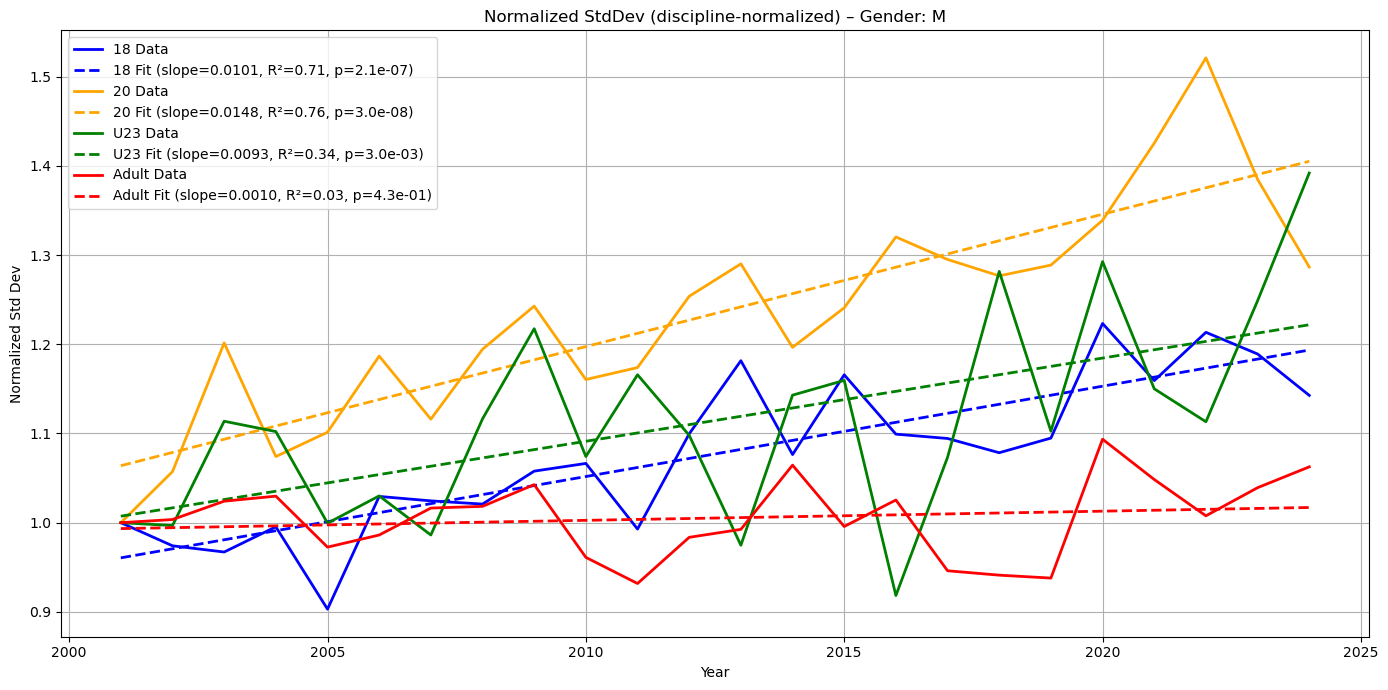

In [71]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import pandas as pd

genders = ['W', 'M']
age_groups = ['18', '20', 'U23', 'Adult']

age_colors = {
    '18': 'blue',
    '20': 'orange',
    'U23': 'green',
    'Adult': 'red'
}

for gender in genders:
    plt.figure(figsize=(14,7))

    for age in age_groups:

        # Fix adult naming
        if age == "Adult":
            age_filter = "Frauen" if gender == "W" else "Maenner"
        else:
            age_filter = age

        # Filter to this gender × age
        base_group = data[(data["geschlecht"] == gender) &(data["altersklasse"] == age_filter)]

        base_group = hp.collect_top_entries(base_group, 30)

        mean_norm = hp.func_norm_per_group(base_group, np.std)

        years = mean_norm.index.values.astype(float)
        vals = mean_norm.values

        X, model, slope, r2, p_value = hp.linear_regression(mean_norm)

        regression_line = model.predict(X)

        plt.plot(years, vals, linestyle='-', color=age_colors[age], linewidth=2, label=f"{age} Data")

        plt.plot(years, regression_line, linestyle='--', color=age_colors[age], linewidth=2, label=f"{age} Fit (slope={slope:.4f}, R²={r2:.2f}, p={p_value:.1e})")

    plt.title(f"Normalized StdDev (discipline-normalized) – Gender: {gender}")
    plt.xlabel("Year")
    plt.ylabel("Normalized Std Dev")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


#### Interpretation

We can see the trend to higher std. in nearly all distributions tested. Key takeaways:

1. Decrease in density in running is highest
2. Decrease in density is higher in men than in woman
3. Adult data is more or less stable, but age groups are diverging

#### Where does the higher standard deviation come from?

-> It can be, that top performances are getting better, but not the rest or the other way around; the top performances are stable, but the rest is getting weaker 

1. What is "top"? Is this discipline individual? Is there a way to define top based on top 30?
2. Which positions are driving the increase in variability?

#### Which "Rank" is contributing "how much" to the variance?

1. Relative contribution: How much is rank 30 in year x differing to baseline year 2001 (Also done within every group  discipline x age group x gender) 

r = rank
g = group (discipline x age group x gender)
S = IAAF Score
y = year

S_rel = S_(g,r)(y) / S_(g,r)(y=2001)

-> removing differences in scales across gender, disciplines

2. Averaging across the subgroups 

mu_r(y) = 1/ num_groups sum over all groups of S_rel_(g,r)(y)

3. Calculating derivation from top 1 rank

diff_r(y) = mu_r(y) - mu_1(y)

This is done to see if a rank is evolving faster or slower than the top performance rank -> difference from the top, competitive spread calculation

We will plot this:

if diff_r(y) is lower than 0 -> diff is lagging behind

4. Square and get fractional contribution of each rank to the total deviation per year

var_r(y) =  diff_r(y) ^2

var_total(y) = sum_r=1to30 var_r(y)

frac_r(y) = var_r(y)/var_total(y)

This is done so we can see how much of the total spread away from the winner is caused by rank r?

Higher ranks (close to 1) usually contribute little; deep ranks dominate variance when the field stretches.

Also we can state, that if lower ranks contribute more, the performance is widening. One might ask "But when we square, we dont know if ranks are improving or declining more than rank 1?" -> That's not the case: They are declining more, because the variance is dependend of rank 1: If a low rank is improving more than rank 1, it would mean it is getting closer to rank 1 -> the variance would be lower -> The contribution is lower. if low ranks catch up, their contribution gets lower. If they fall behind, their contribution grows.

Answering: Who contributes how much to inequality of improvement?

C:\Users\Mattis\AppData\Local\Temp\ipykernel_31016\155581371.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('RdYlGn_r', top_n)  # rank 1=green, rank 30=red


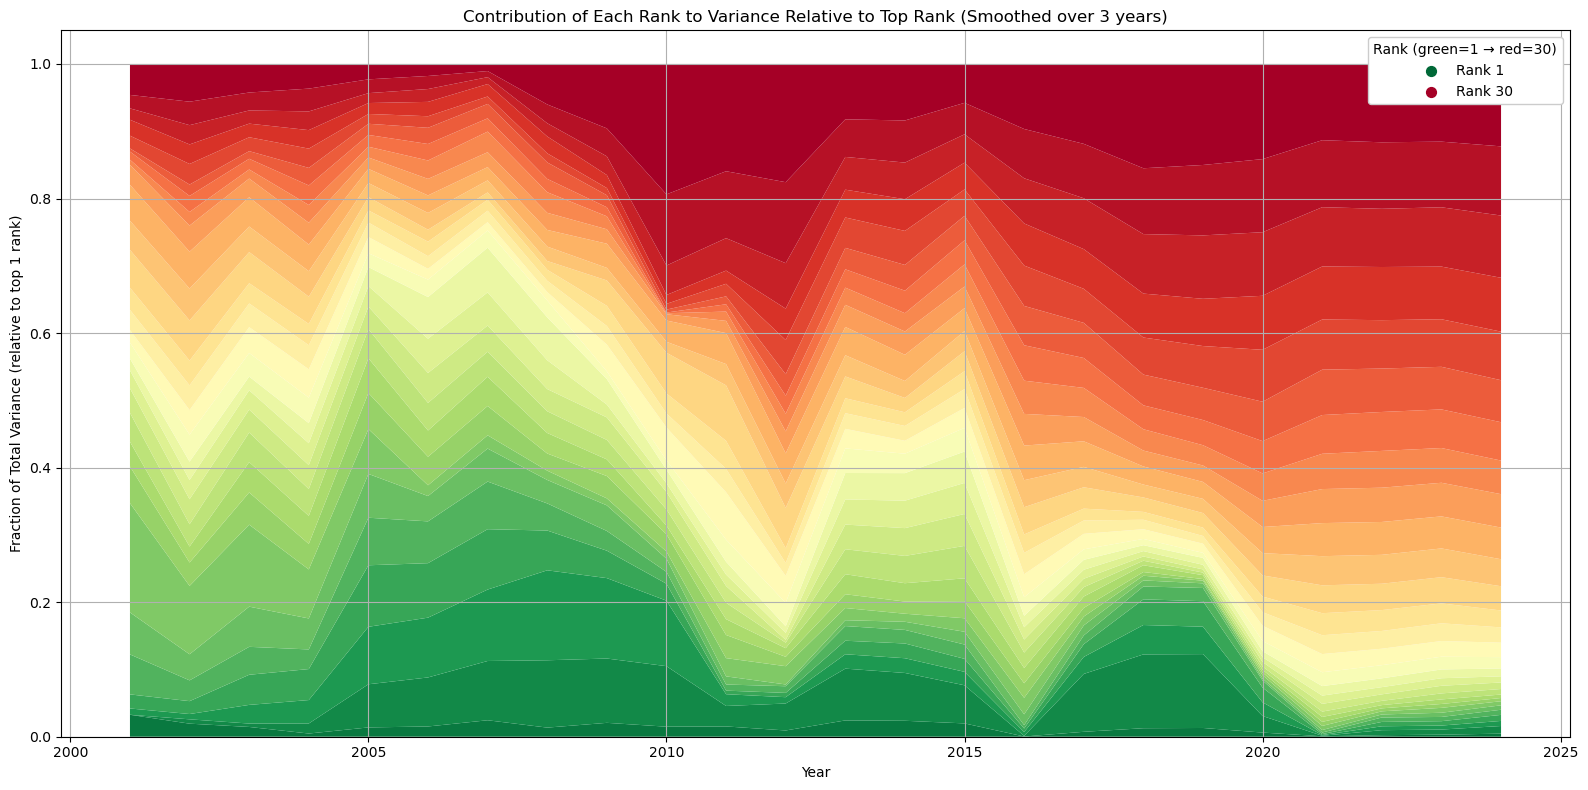

C:\Users\Mattis\AppData\Local\Temp\ipykernel_31016\155581371.py:67: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('RdYlGn_r', top_n)


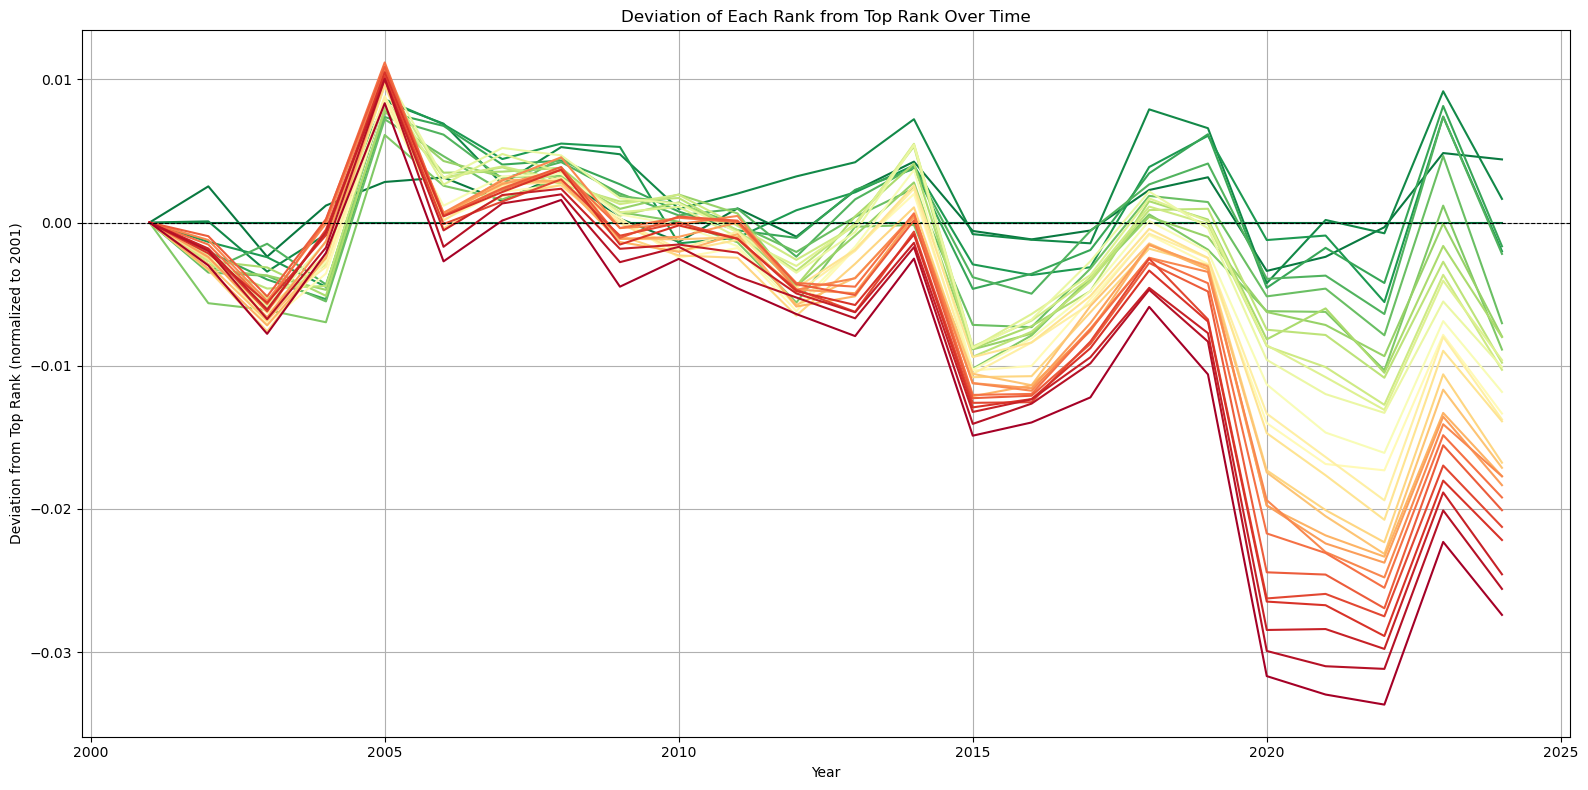

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

top_n = 30
years = sorted(data['jahr'].unique())

# 1. Collect normalized scores per rank per subgroup
S_rel_gr_list = {r: [] for r in range(1, top_n+1)}

for (disc, gender, age), subdata in top_raw.groupby(["disziplin","geschlecht","altersklasse"]):
    S_g = subdata.groupby("jahr")["iaaf_score"].apply(
        lambda x: x.sort_values(ascending=False).head(top_n).values
    )
    
    if 2001 not in S_g.index:
        continue

    S_gr = pd.DataFrame({year: vals for year, vals in zip(S_g.index, S_g.values)}).T
    S_gr.columns = range(1, top_n+1)
    S_gr.index.name = "jahr"

    # Normalize to 2001
    S_rel_gr = S_gr / S_gr.loc[2001]

    # Store per rank
    for r in range(1, top_n+1):
        S_rel_gr_list[r].append(S_rel_gr[r])


# Compute mean per rank across subgroups
mu_r = pd.DataFrame({r: pd.concat(series, axis=1).mean(axis=1) 
                                   for r, series in S_rel_gr_list.items()})
mu_r = mu_r.sort_index()

# Compute fraction of total variance per rank **relative to top rank**
diff_r = mu_r.subtract(mu_r[1], axis=0)  # rank 1 as reference

var_r = diff_r**2
total_var = var_r.sum(axis=1)

frac_var_r = var_r.div(total_var, axis=0)

# --- Optional: smooth over 3 years ---
frac_var_r_smooth = frac_var_r.rolling(window=3, min_periods=1, center=True).mean()

# 4. Plot stacked area chart for all 30 ranks
plt.figure(figsize=(16,8))
colors = plt.cm.get_cmap('RdYlGn_r', top_n)  # rank 1=green, rank 30=red


plt.stackplot(frac_var_r_smooth.index, frac_var_r_smooth.T, colors=[colors(i) for i in range(top_n)])
plt.xlabel("Year")
plt.ylabel("Fraction of Total Variance (relative to top 1 rank)")
plt.title("Contribution of Each Rank to Variance Relative to Top Rank (Smoothed over 3 years)")
plt.grid(True)
# Add a dot gradient legend
for i in range(top_n):
    plt.scatter([], [], color=colors(i), s=50, label=f'Rank {i+1}' if i in [0, top_n-1] else "_nolegend_")

plt.legend(loc='upper right', title='Rank (green=1 → red=30)', framealpha=1)
plt.tight_layout()
plt.show()
# 5. Plot deviations from top rank over time
plt.figure(figsize=(16,8))
colors = plt.cm.get_cmap('RdYlGn_r', top_n)

for r in range(1, top_n+1):
    plt.plot(diff_r.index, diff_r[r], color=colors(r-1), label=f"Rank {r}")

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Deviation from Top Rank (normalized to 2001)")
plt.title("Deviation of Each Rank from Top Rank Over Time")
plt.grid(True)
plt.tight_layout()
plt.show()



As we can see, the **contribution to the variance is getting larger for lower ranks** -> They are falling behind relative to the top

Plot 2 Shows that also ~2005 the lower ranks are getting closer and improving towards the top 1, but afterwards genually falling behind